In [1]:
%matplotlib inline
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import madrigalWeb.madrigalWeb
import os
import h5py
import numpy as np

In [2]:
#CHANGE ME
user_fullname = "Benjamin Marcotte"
user_email = "bmarc@bu.edu"
user_affiliation = "ISR Summer School 2026"

#maddat = madrigalWeb.madrigalWeb.MadrigalData('https://data.amisr.com/madrigal/')
maddat = madrigalWeb.madrigalWeb.MadrigalData('https://cedar.openmadrigal.org/')

In [3]:
#instrument codes for AMISR
instcodes={'PFISR':61,
          'RISR-N':91,
          'RISR-C':92}

In [8]:
# Find an experiment that happened in the following time interval:
st=datetime.datetime(2024, 6, 4, 0,0)
et=datetime.datetime(2024, 6, 4, 23,59)

expList = maddat.getExperiments(instcodes['PFISR'],
                st.year, st.month, st.day, st.hour, st.minute, st.second,
                et.year, et.month, et.day, et.hour, et.minute, et.second)
for exp in expList:
    print(exp)

id: 100011552
realUrl: https://cedar.openmadrigal.org/showExperiment/?experiment_list=100011552
url: https://cedar.openmadrigal.org/madtoc/experiments4/2024/pfa/03jun24b
name: IPY27_Tracking_v03 - Long duration measurements in support of the International Polar Year
siteid: 10
sitename: CEDAR
instcode: 61
instname: Poker Flat IS Radar
startyear: 2024
startmonth: 6
startday: 3
starthour: 10
startmin: 47
startsec: 45
endyear: 2024
endmonth: 6
endday: 4
endhour: 8
endmin: 44
endsec: 57
isLocal: True
madrigalUrl: http://https://cedar.openmadrigal.org/
PI: Asti Bhatt
PIEmail: asti.bhatt@sri.com
uttimestamp: 1735087065
access: 2
Madrigal version: 3.2

id: 100011612
realUrl: https://cedar.openmadrigal.org/showExperiment/?experiment_list=100011612
url: https://cedar.openmadrigal.org/madtoc/experiments4/2024/pfa/04jun24a
name: LLITED.v01 - Conjunction with LLITED Cubesat
siteid: 10
sitename: CEDAR
instcode: 61
instname: Poker Flat IS Radar
startyear: 2024
startmonth: 6
startday: 4
starthour: 8


In [9]:
# Get all the files associated with the experiment:
fileList = maddat.getExperimentFiles(expList[0].id)
for file in fileList:
    print(os.path.basename(file.name),'\tkindat:',file.kindat,'desc:',file.kindatdesc)

pfa20240603.002_ac_nenotr_01min.001.h5 	kindat: 1000201 desc: Ne From Power - Alternating Code (E-region) - 1 min
pfa20240603.002_ac_fit_01min.001.h5 	kindat: 2000201 desc: Fitted - Alternating Code (E-region) - 1 min
pfa20240603.002_ac_nenotr_03min.001.h5 	kindat: 1000203 desc: Ne From Power - Alternating Code (E-region) - 3 min
pfa20240603.002_ac_fit_03min.001.h5 	kindat: 2000203 desc: Fitted - Alternating Code (E-region) - 3 min
pfa20240603.002_ac_nenotr_05min.001.h5 	kindat: 1000205 desc: Ne From Power - Alternating Code (E-region) - 5 min
pfa20240603.002_ac_fit_05min.001.h5 	kindat: 2000205 desc: Fitted - Alternating Code (E-region) - 5 min
pfa20240603.002_ac_nenotr_10min.001.h5 	kindat: 1000210 desc: Ne From Power - Alternating Code (E-region) - 10 min
pfa20240603.002_ac_fit_10min.001.h5 	kindat: 2000210 desc: Fitted - Alternating Code (E-region) - 10 min
pfa20240603.002_ac_nenotr_15min.001.h5 	kindat: 1000215 desc: Ne From Power - Alternating Code (E-region) - 15 min
pfa20240603

In [10]:
# Download a specific file from the experiment
fileList = maddat.getExperimentFiles(expList[0].id)
acfile=None
for file in fileList:
    if file.kindat == 2000110: # New kindat for Fitted - Alternating Code (E-region) - 3 min 
        acfile=file
        break
        
filename    = acfile.name
outfilename = os.path.basename(acfile.name)
result = maddat.downloadFile(filename,outfilename, user_fullname, user_email, user_affiliation, 'hdf5')
print(f"Done downloading {outfilename}")

Done downloading pfa20240603.002_lp_fit_10min.001.h5


In [11]:
# Explore the HDF5 madrigal metadata
with h5py.File(outfilename,'r') as f:
    for key1,val1 in f.items():
        print(key1,val1)
        for key2,val2 in val1.items():
            print(" ",key2,val2)        

Data <HDF5 group "/Data" (2 members)>
  Array Layout <HDF5 group "/Data/Array Layout" (4 members)>
  Table Layout <HDF5 dataset "Table Layout": shape (49780,), type "|V288">
Metadata <HDF5 group "/Metadata" (6 members)>
  Data Parameters <HDF5 dataset "Data Parameters": shape (36,), type "|V99">
  Experiment Notes <HDF5 dataset "Experiment Notes": shape (90,), type "|V8">
  Experiment Parameters <HDF5 dataset "Experiment Parameters": shape (14,), type "|V16">
  Independent Spatial Parameters <HDF5 dataset "Independent Spatial Parameters": shape (1,), type "|V10">
  Parameters Used to Split Array Data <HDF5 dataset "Parameters Used to Split Array Data": shape (1,), type "|V21">
  _record_layout <HDF5 dataset "_record_layout": shape (1,), type "|V288">


In [12]:
# Explore the HDF5 madrigal data from the first beam in /Data/Array Layout
with h5py.File(outfilename,'r') as f:
    for key1,val1 in f["/Data/Array Layout"].items():
        print(key1,val1)
        for key2,val2 in val1.items():
            print(" ",key2,val2) 
            try:
                for key3,val3 in val2.items():
                    print("   ",key3,val3)      
            except:
                pass
        break

Array with beamid=64016  <HDF5 group "/Data/Array Layout/Array with beamid=64016 " (5 members)>
  1D Parameters <HDF5 group "/Data/Array Layout/Array with beamid=64016 /1D Parameters" (11 members)>
    Data Parameters <HDF5 dataset "Data Parameters": shape (10,), type "|V88">
    azm <HDF5 dataset "azm": shape (131,), type "<f8">
    beamid <HDF5 dataset "beamid": shape (131,), type "<i8">
    cbadl <HDF5 dataset "cbadl": shape (131,), type "<f8">
    elm <HDF5 dataset "elm": shape (131,), type "<f8">
    numrxaeu <HDF5 dataset "numrxaeu": shape (131,), type "<f8">
    numtxaeu <HDF5 dataset "numtxaeu": shape (131,), type "<f8">
    pl <HDF5 dataset "pl": shape (131,), type "<f8">
    power <HDF5 dataset "power": shape (131,), type "<f8">
    rfreq <HDF5 dataset "rfreq": shape (131,), type "<f8">
    tfreq <HDF5 dataset "tfreq": shape (131,), type "<f8">
  2D Parameters <HDF5 group "/Data/Array Layout/Array with beamid=64016 /2D Parameters" (15 members)>
    Data Parameters <HDF5 datas

In [13]:
with h5py.File(outfilename,'r') as f:
    PFISR_data = []
    for dat in f['Data/Array Layout'].values():
        outdct={}
        outdct['bid'] = dat['1D Parameters/beamid'][0]
        outdct['azm'] = dat['1D Parameters/azm'][0]
        outdct['elm'] = dat['1D Parameters/elm'][0]
        outdct['ne'] = dat['2D Parameters/ne'][:]     # different from old SRI madrigal 2
        outdct['dne'] = dat['2D Parameters/dne'][:]   # different from old SRI madrigal 2
        outdct['te'] = dat['2D Parameters/te'][:]
        outdct['dte'] = dat['2D Parameters/dte'][:]
        outdct['ti'] = dat['2D Parameters/ti'][:]
        outdct['dti'] = dat['2D Parameters/dti'][:]
        outdct['vo'] = dat['2D Parameters/vo'][:]
        outdct['dvo'] = dat['2D Parameters/dvo'][:]
        
        outdct['range'] = dat['range'][:]
        outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
        tstmp = dat['timestamps'][:]
        outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]
        PFISR_data.append(outdct)

In [14]:
for i,d in enumerate(PFISR_data):
    print(d['bid'],d['azm'],d['elm'])

64016 14.039999961853027 90.0
64157 -154.3000030517578 77.5
64964 -34.689998626708984 66.08999633789062
65066 75.02999877929688 65.55999755859375


In [15]:
#find the up-B beam : 64157 az = -154.3, el = 77.5
beam_index = np.argmin(np.abs(np.array([x['elm'] for x in PFISR_data]) - ( 77.5)))
beam_data = PFISR_data[beam_index]

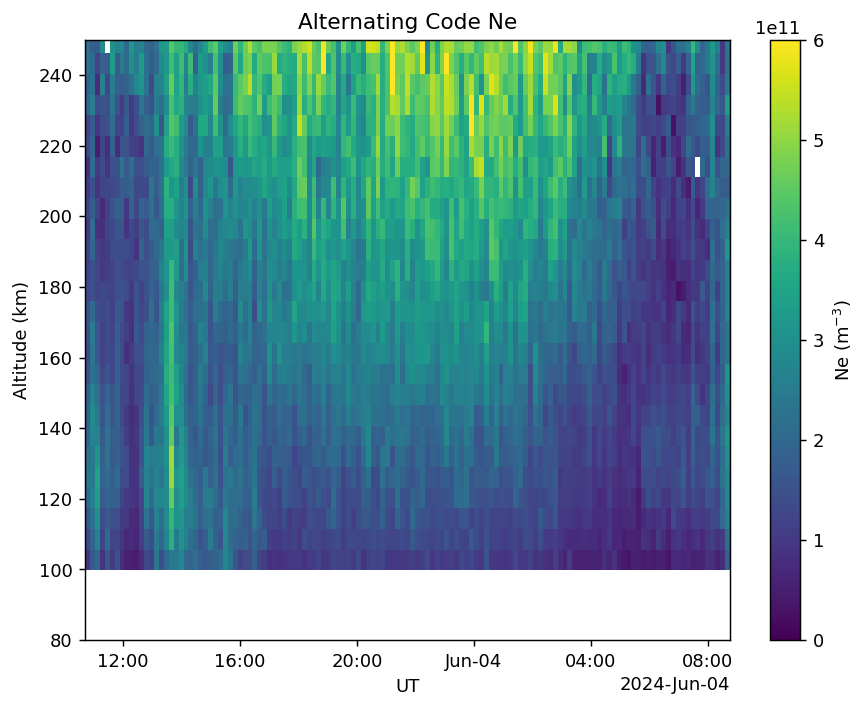

In [16]:
fig,ax=plt.subplots(figsize=(8,6), dpi=130)
clrs = ax.pcolormesh(mdates.date2num(beam_data['time']),
                     beam_data['altitude']/1e3,
                     beam_data['ne'],
                     vmin=0,vmax=6e11,shading='nearest')

locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_ylim([80,250])

ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title('Alternating Code Ne')

cb=fig.colorbar(clrs)
cb.set_label('Ne (m$^{-3}$)')

# Questions

1. What is producing the E-region electron density in this plot?

2. How do the density profiles differ before and after 11 UT?

3. Use https://www.gi.alaska.edu/monitors/magnetometer/archive to find the Poker Flat Magnetometer data from this same date and time. Does anything special happen in the magnetometer data that lines up with an event in the PFISR data?